In [1]:
pip install numpy pandas matplotlib seaborn scikit-learn scipy flask joblib requests

Note: you may need to restart the kernel to use updated packages.


### Task 1 — Unsupervised Exploration

1. Load the Palmer Penguins dataset (`sns.load_dataset("penguins")`).
2. Clean the data: handle missing values, examine distributions, and note any anomalies.
3. Select the numeric features and scale them with `StandardScaler`.
4. Apply **PCA** (2 components) and **t-SNE** (2 components, `random_state=42`). Create a side-by-side plot colored by actual species.
5. Apply **K-Means** (k=3) and **DBSCAN** (experiment with at least 2 `eps`/`min_samples` combos) to the scaled data.
6. Evaluate each clustering result with the **silhouette score**.
7. Compare your best clustering labels to the actual species using **adjusted Rand score** and **normalized mutual information**. Visualize the comparison on a PCA projection.
8. In a markdown cell, summarize: How well did unsupervised methods recover the species structure? Where did they fail?



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)

In [3]:
import seaborn as sns

df = sns.load_dataset("penguins")
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [4]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [5]:
df_clean = df.dropna().reset_index(drop=True)
print(f"\nRows after dropping NaNs: {len(df_clean)}  (removed {len(df) - len(df_clean)})")



Rows after dropping NaNs: 333  (removed 11)


In [6]:
df_clean

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
328,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
329,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
330,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
331,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [7]:
print("\nSpecies distribution:")
print(df_clean["species"].value_counts())


Species distribution:
species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64


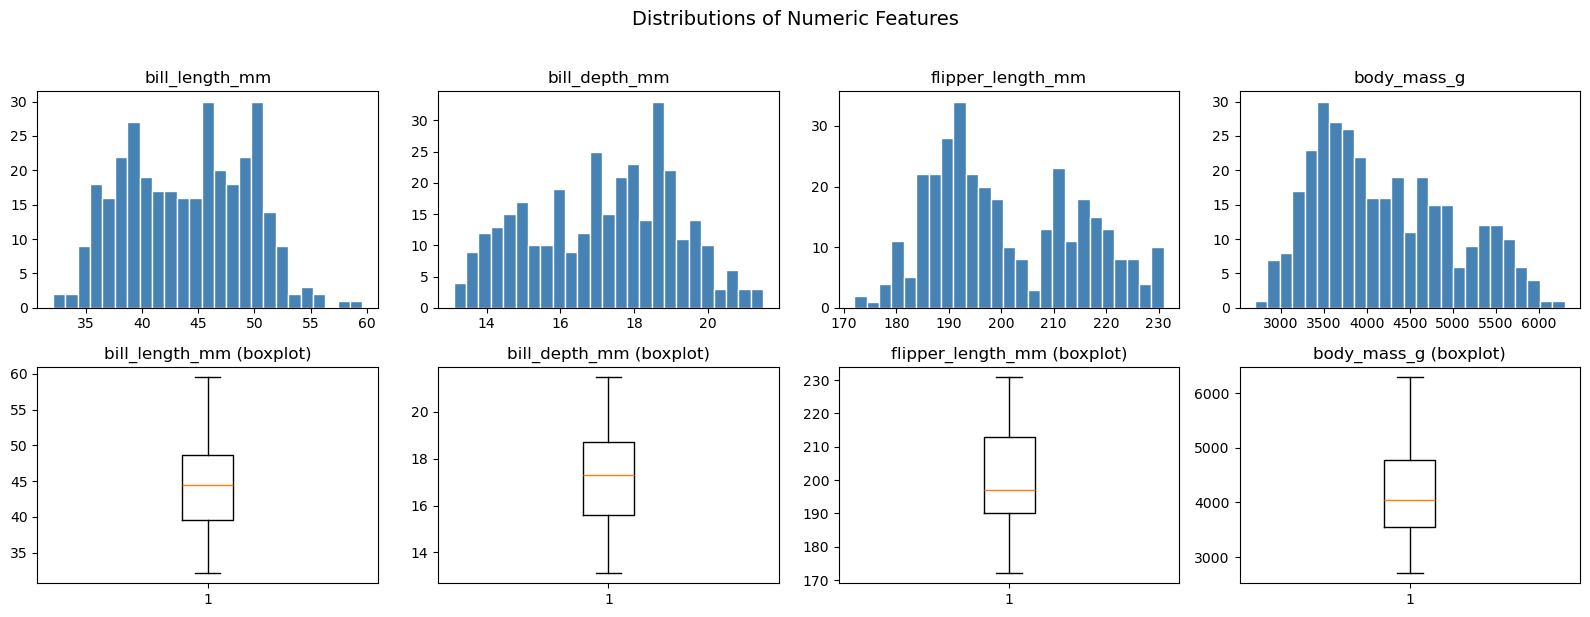

In [8]:
numeric_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for i, col in enumerate(numeric_cols):
    axes[0, i].hist(df_clean[col], bins=25, color="steelblue", edgecolor="white")
    axes[0, i].set_title(col)
    axes[1, i].boxplot(df_clean[col])
    axes[1, i].set_title(f"{col} (boxplot)")

plt.suptitle("Distributions of Numeric Features", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [9]:
X = df_clean[numeric_cols].values
y_true = df_clean["species"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled means:", X_scaled.mean(axis=0).round(4))
print("Scaled stds:", X_scaled.std(axis=0))

Scaled means: [ 0.  0.  0. -0.]
Scaled stds: [1. 1. 1. 1.]


In [10]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA explained variance ratio: {pca.explained_variance_ratio_.round(3)}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.1%}")

PCA explained variance ratio: [0.686 0.195]
Total variance explained: 88.1%


In [11]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

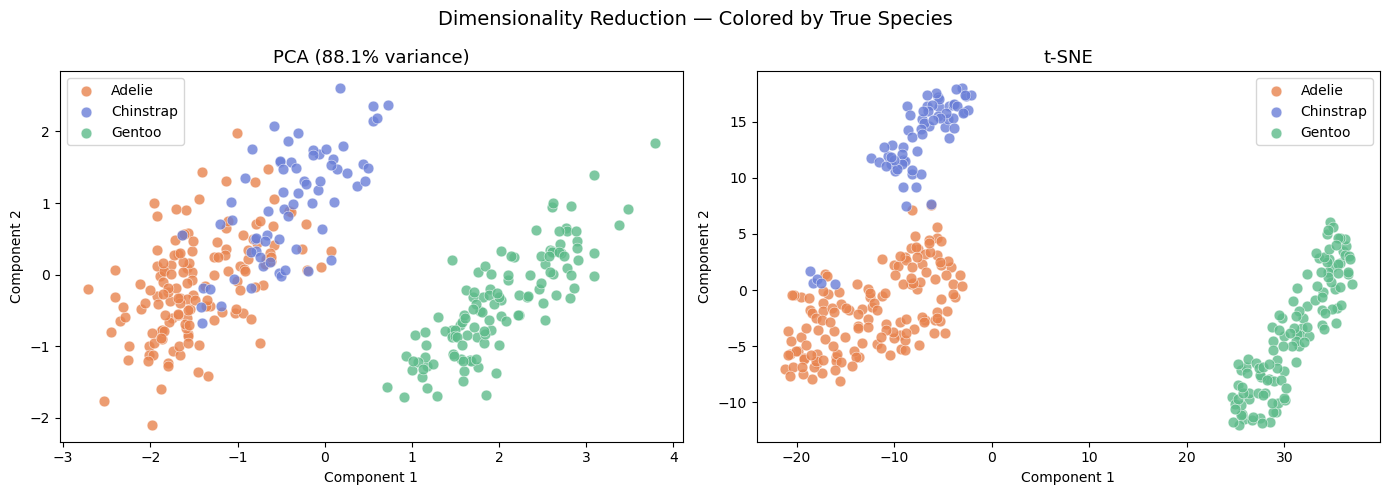

In [12]:
species_colors = {"Adelie": "#E8834E", "Chinstrap": "#6B7FD7", "Gentoo": "#5DBB8A"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, X_embed, title in zip(
    axes,
    [X_pca, X_tsne],
    [f"PCA ({pca.explained_variance_ratio_.sum():.1%} variance)", "t-SNE"],
):
    for species, color in species_colors.items():
        mask = y_true == species
        ax.scatter(X_embed[mask, 0], X_embed[mask, 1],
                   c=color, label=species, alpha=0.8,
                   edgecolors="white", linewidths=0.4, s=60)
    ax.set_title(title, fontsize=13)
    ax.legend()
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")

plt.suptitle("Dimensionality Reduction — Colored by True Species", fontsize=14)
plt.tight_layout()
plt.show()


In [13]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)

sil_kmeans = silhouette_score(X_scaled, labels_kmeans)
print(f"K-Means (k=3) Silhouette Score: {sil_kmeans:.4f}")

K-Means (k=3) Silhouette Score: 0.4462


C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [14]:
dbscan_configs = [
    {"eps": 0.5, "min_samples": 5},
    {"eps": 0.8, "min_samples": 5},
    {"eps": 0.8, "min_samples": 10},
    
]

dbscan_results = []
for cfg in dbscan_configs:
    db = DBSCAN(eps=cfg["eps"], min_samples=cfg["min_samples"])
    labels = db.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    mask = labels != -1
    sil = silhouette_score(X_scaled[mask], labels[mask]) if (n_clusters >= 2 and mask.sum() > 1) else -1
    dbscan_results.append({
        "eps": cfg["eps"], "min_samples": cfg["min_samples"],
        "n_clusters": n_clusters, "n_noise": n_noise,
        "silhouette": round(sil, 4), "labels": labels,
    })

pd.DataFrame(dbscan_results).drop(columns="labels")

,eps,min_samples,n_clusters,n_noise,silhouette
0,0.5,5,4,66,0.4223
1,0.8,5,2,5,0.5351
2,0.8,10,2,10,0.5412


In [15]:
print(f"{'Method':<40} {'Silhouette':>10} {'Clusters':>10} {'Noise':>7}")
print("-" * 70)
print(f"{'K-Means (k=3)':<40} {sil_kmeans:>10.4f} {'3':>10} {'-':>7}")
for r in dbscan_results:
    name = f"DBSCAN eps={r['eps']}, min_samples={r['min_samples']}"
    print(f"{name:<40} {r['silhouette']:>10.4f} {r['n_clusters']:>10} {r['n_noise']:>7}")

Method                                   Silhouette   Clusters   Noise
----------------------------------------------------------------------
K-Means (k=3)                                0.4462          3       -
DBSCAN eps=0.5, min_samples=5                0.4223          4      66
DBSCAN eps=0.8, min_samples=5                0.5351          2       5
DBSCAN eps=0.8, min_samples=10               0.5412          2      10


In [16]:
le = LabelEncoder()
y_encoded = le.fit_transform(y_true)

best_dbscan = max(
    [r for r in dbscan_results if r["n_clusters"] >= 2],
    key=lambda x: x["silhouette"],
)
labels_dbscan_best = best_dbscan["labels"]
mask_db = labels_dbscan_best != -1

ari_kmeans = adjusted_rand_score(y_encoded, labels_kmeans)
nmi_kmeans = normalized_mutual_info_score(y_encoded, labels_kmeans)
ari_dbscan = adjusted_rand_score(y_encoded[mask_db], labels_dbscan_best[mask_db])
nmi_dbscan = normalized_mutual_info_score(y_encoded[mask_db], labels_dbscan_best[mask_db])

print(f"{'Method':<35} {'ARI':>8} {'NMI':>8}")
print("-" * 53)
print(f"{'K-Means (k=3)':<35} {ari_kmeans:>8.4f} {nmi_kmeans:>8.4f}")
print(f"{'DBSCAN (best, excl. noise)':<35} {ari_dbscan:>8.4f} {nmi_dbscan:>8.4f}")

Method                                   ARI      NMI
-----------------------------------------------------
K-Means (k=3)                         0.7994   0.7899
DBSCAN (best, excl. noise)            0.6553   0.7672


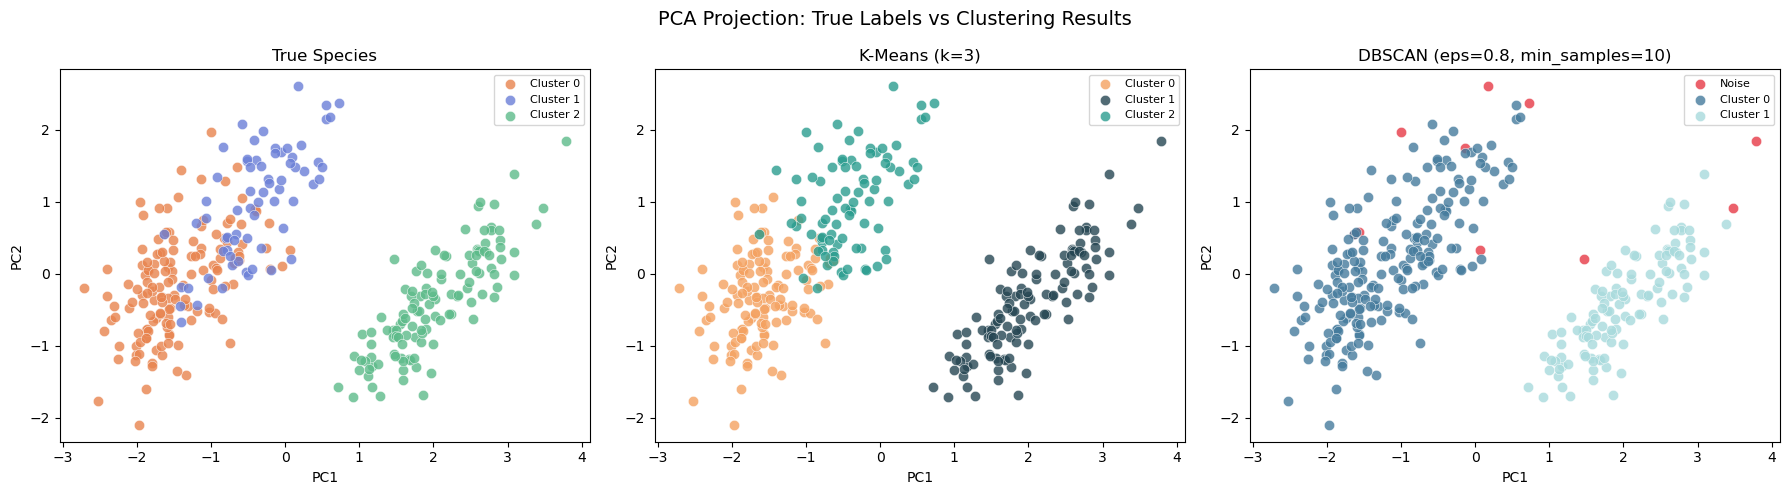

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_data = [
    (y_encoded,          "True Species",
     ["#E8834E", "#6B7FD7", "#5DBB8A"]),
    (labels_kmeans,      "K-Means (k=3)",
     ["#F4A261", "#264653", "#2A9D8F"]),
    (labels_dbscan_best,
     f"DBSCAN (eps={best_dbscan['eps']}, min_samples={best_dbscan['min_samples']})",
     ["#E63946", "#457B9D", "#A8DADC", "#999999"]),
]

for ax, (labels, title, palette) in zip(axes, plot_data):
    for i, lbl in enumerate(sorted(set(labels))):
        mask = labels == lbl
        label_name = "Noise" if lbl == -1 else f"Cluster {lbl}"
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=palette[i % len(palette)], label=label_name,
                   alpha=0.8, edgecolors="white", linewidths=0.4, s=55)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=8)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.suptitle("PCA Projection: True Labels vs Clustering Results", fontsize=14)
plt.tight_layout()
plt.show()

### Method Breakdown

#### K-Means (k = 3)

**Results:**
- Silhouette Score: 0.4462  
- ARI: 0.7994  
- NMI: 0.7899  

**Interpretation:**
K-Means achieved the highest alignment with the true labels (ARI = 0.7994), making it the most accurate method in this task. By enforcing three clusters, it successfully captured the existence of three species.

However, due to the overlap between Adelie and Chinstrap, K-Means created linear decision boundaries that cut through the mixed region. This led to some misclassifications and a lower silhouette score compared to DBSCAN.


#### DBSCAN (eps = 0.8, min_samples = 10)

**Results:**
- Silhouette Score: 0.5412  
- ARI: 0.6553  
- NMI: 0.7672  
- Clusters Found: 2  
- Noise Points: 10  

**Interpretation:**
DBSCAN achieved a higher silhouette score (0.5412), indicating tighter and more separated clusters. However, this result is misleading.

Instead of identifying three species, DBSCAN detected only two clusters, merging Adelie and Chinstrap into a single group. This occurred because the density between these species forms a continuous “bridge,” preventing the algorithm from separating them.

While DBSCAN successfully identified noise points, this did not improve its ability to recover the true class structure.


### Key Insight

Although DBSCAN achieved a higher silhouette score, it performed worse in terms of matching the true species labels (ARI = 0.6553) compared to K-Means (ARI = 0.7994).

This highlights an important point:
> A higher silhouette score does not necessarily indicate better recovery of real-world classes.


### Conclusion

The unsupervised methods successfully captured the global structure of the dataset, particularly the clear separation of the Gentoo species.

However, they failed to fully distinguish between Adelie and Chinstrap due to their overlapping feature distributions.

Overall, K-Means is the more effective method in this case, as it correctly identified three clusters and achieved better alignment with the true labels, whereas DBSCAN simplified the structure into two clusters and lost important class distinctions.

### Task 2 — Supervised Model Pipeline

1. Prepare the full dataset for supervised classification: target = `species`, features = all other columns.
2. Drop rows with missing values using `dropna()`, then build a preprocessing pipeline using `ColumnTransformer`:
   - Numeric features: scale (`StandardScaler`).
   - Categorical features: one-hot encode (`OneHotEncoder`).
3. Train and evaluate **at least 3 different models** (e.g., LogisticRegression, RandomForest, SVC) using **stratified 5-fold cross-validation**. Report accuracy, precision (macro), recall (macro), and F1 (macro) for each.
4. Select the best model based on F1 score.
5. Define a hyperparameter grid (at least 3 parameters) and run `GridSearchCV` with stratified 5-fold CV.
6. Report the best parameters, best CV score, and compare with the default model performance.

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import make_scorer, f1_score
import warnings
warnings.filterwarnings("ignore")

In [19]:
target = "species"
features = [col for col in df_clean.columns if col != target]

X = df_clean[features]
y = df_clean[target]

print("Features:", features)
print("Shape:", X.shape)
print("\nClass distribution:")
print(y.value_counts())

Features: ['island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']
Shape: (333, 6)

Class distribution:
species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64


In [20]:
numeric_features = X.select_dtypes(include=["float64", "int64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(),numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
])

Numeric features: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
Categorical features: ['island', 'sex']


In [21]:
models = {
    "Logistic Regression":LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVC":SVC(kernel="rbf", random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy":"accuracy",
    "precision": make_scorer(f1_score, average="macro"),
    "recall":make_scorer(f1_score, average="macro"),
    "f1": make_scorer(f1_score, average="macro"),
}

results = {}
for name, model in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("classifier", model)])
    cv_res = cross_validate(pipe, X, y, cv=cv, scoring=scoring)
    results[name] = {
        "Accuracy":cv_res["test_accuracy"].mean(),
        "Precision (mac)":cv_res["test_precision"].mean(),
        "Recall (mac)":cv_res["test_recall"].mean(),
        "F1 (macro)":cv_res["test_f1"].mean(),
    }

results_df = pd.DataFrame(results).T.round(4)
print(results_df.to_string())

                     Accuracy  Precision (mac)  Recall (mac)  F1 (macro)
Logistic Regression     0.994           0.9923        0.9923      0.9923
Random Forest           0.991           0.9891        0.9891      0.9891
SVC                     0.994           0.9923        0.9923      0.9923


In [22]:
best_model_name = results_df["F1 (macro)"].idxmax()
best_f1_default = results_df.loc[best_model_name, "F1 (macro)"]

print(f"Best model (by F1): {best_model_name}")
print(f"Default CV F1: {best_f1_default:.4f}")

Best model (by F1): Logistic Regression
Default CV F1: 0.9923


In [23]:
grids = {
    "Logistic Regression": {
        "classifier__C":[0.01, 0.1, 1, 10, 100],
        "classifier__solver":["lbfgs", "saga"],
        "classifier__max_iter":[500, 1000],
    },
    "Random Forest": {
        "classifier__n_estimators":[50, 100, 200],
        "classifier__max_depth":[None, 5, 10],
        "classifier__min_samples_split":[2, 5, 10],
    },
    "SVC": {
        "classifier__C":[0.1, 1, 10, 100],
        "classifier__kernel":["rbf", "linear"],
        "classifier__gamma":["scale", "auto"],
    },
}

pipe_grid = Pipeline([
    ("preprocessor",preprocessor),
    ("classifier",models[best_model_name]),
])

grid_search = GridSearchCV(
    pipe_grid,
    grids[best_model_name],
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X, y)

print(f"\nBest parameters:\n{grid_search.best_params_}")
print(f"\nBest CV F1 (GridSearch): {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters:
{'classifier__C': 0.1, 'classifier__max_iter': 500, 'classifier__solver': 'lbfgs'}

Best CV F1 (GridSearch): 0.9923


In [24]:
comparison = pd.DataFrame({
    "Config": ["Default", "GridSearchCV"],
    "CV F1":  [best_f1_default, grid_search.best_score_],
}).set_index("Config")

print(comparison.round(4).to_string())
print(f"\nImprovement: {(grid_search.best_score_ - best_f1_default)*100}%")

               CV F1
Config              
Default       0.9923
GridSearchCV  0.9923

Improvement: -0.0006093189964140322%


In [25]:
cv_df = pd.DataFrame(grid_search.cv_results_)
top10 = (
    cv_df[["params", "mean_test_score", "std_test_score", "rank_test_score"]]
    .sort_values("rank_test_score")
    .head(10)
    .reset_index(drop=True)
)
top10.columns = ["Params", "Mean F1", "Std F1", "Rank"]
top10["Mean F1"] = top10["Mean F1"].round(4)
top10["Std F1"]  = top10["Std F1"].round(4)
print(top10.to_string())

                                                                                Params  Mean F1  Std F1  Rank
0      {'classifier__C': 1, 'classifier__max_iter': 500, 'classifier__solver': 'saga'}   0.9923  0.0154     1
1     {'classifier__C': 1, 'classifier__max_iter': 1000, 'classifier__solver': 'saga'}   0.9923  0.0154     1
2   {'classifier__C': 0.1, 'classifier__max_iter': 500, 'classifier__solver': 'lbfgs'}   0.9923  0.0154     1
3    {'classifier__C': 0.1, 'classifier__max_iter': 500, 'classifier__solver': 'saga'}   0.9923  0.0154     1
4  {'classifier__C': 0.1, 'classifier__max_iter': 1000, 'classifier__solver': 'lbfgs'}   0.9923  0.0154     1
5   {'classifier__C': 0.1, 'classifier__max_iter': 1000, 'classifier__solver': 'saga'}   0.9923  0.0154     1
6     {'classifier__C': 1, 'classifier__max_iter': 500, 'classifier__solver': 'lbfgs'}   0.9923  0.0154     1
7    {'classifier__C': 1, 'classifier__max_iter': 1000, 'classifier__solver': 'lbfgs'}   0.9923  0.0154     1
8    {'cla

### Results overview

All three models achieved remarkably high performance on this dataset:

| Model               | Accuracy | Precision | Recall | F1     |
|---------------------|----------|-----------|--------|--------|
| Logistic Regression | 0.9940   | 0.9923    | 0.9923 | 0.9923 |
| SVC                 | 0.9940   | 0.9923    | 0.9923 | 0.9923 |
| Random Forest       | 0.9910   | 0.9891    | 0.9891 | 0.9891 |

**Best model:** Logistic Regression (tied with SVC), selected by F1 = 0.9923.

### Why such high scores?

Including categorical features (island, sex) alongside the numeric ones
gives the classifier much richer signal than Task 1's numeric-only setup.
Island alone is a near-perfect proxy for Gentoo penguins (Biscoe island),
which explains why even a linear model like Logistic Regression achieves ~99% F1.

### GridSearchCV findings

- Grid searched over C ∈ {0.01, 0.1, 1, 10, 100}, solver ∈ {lbfgs, saga},
  max_iter ∈ {500, 1000} → 20 candidates × 5 folds = 100 fits.
- Best parameters: C=0.1, solver=lbfgs, max_iter=500.
- Best CV F1: 0.9923 — identical to the default model.
- Improvement: ~0.00% (effectively zero).


The default Logistic Regression was already at the performance ceiling
of this dataset. With F1 = 0.9923, the remaining 0.77% error is likely
irreducible noise (a handful of borderline Adelie/Chinstrap individuals
whose features genuinely overlap). No amount of regularization tuning
can separate points that are fundamentally ambiguous.


### Task 3 — Model Evaluation & Interpretation

Using the best tuned model from Task 2:

1. Train on the full training set and predict on a held-out test set (80/20 split, `random_state=42`).
2. Print the full **classification report**.
3. Plot the **confusion matrix** using `ConfusionMatrixDisplay`.
4. Plot **ROC curves** (one-vs-rest) for all three species on the same figure. Compute and display the AUC for each class. (If your model doesn't natively support `predict_proba`, wrap it in a `CalibratedClassifierCV` or switch to a model that does.)
5. Plot **learning curves** (training size from 10% to 100%).
6. Compute **permutation importances** on the test set and plot the top features.
7. In a markdown cell, write a comprehensive interpretation:
   - Is the model overfitting or underfitting?
   - Which species is hardest to classify and why?
   - Which features drive predictions the most?
   - Are there any signs of data leakage or evaluation issues?


In [26]:
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from sklearn.inspection import permutation_importance
import matplotlib.gridspec as gridspec

In [27]:
best_pipeline = grid_search.best_estimator_

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Train size: 266 | Test size: 67


In [28]:
print("Classification Report")
print("=" * 50)
print(classification_report(y_test, y_pred, digits=4))

Classification Report
              precision    recall  f1-score   support

      Adelie     1.0000    1.0000    1.0000        29
   Chinstrap     1.0000    1.0000    1.0000        14
      Gentoo     1.0000    1.0000    1.0000        24

    accuracy                         1.0000        67
   macro avg     1.0000    1.0000    1.0000        67
weighted avg     1.0000    1.0000    1.0000        67



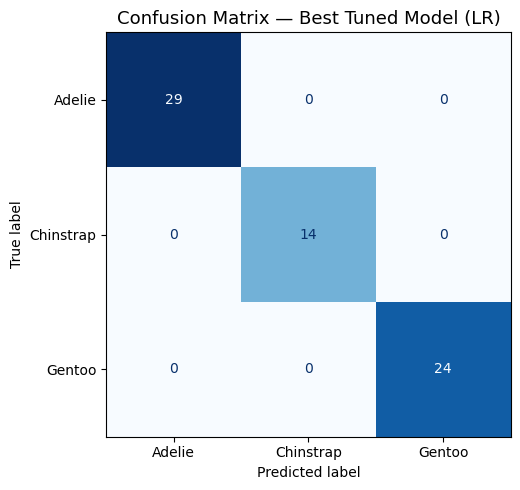

In [29]:
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=best_pipeline.classes_,
    colorbar=False,
    cmap="Blues",
    ax=ax,
)

ax.set_title("Confusion Matrix — Best Tuned Model (LR)", fontsize=13)
plt.tight_layout()
plt.show()

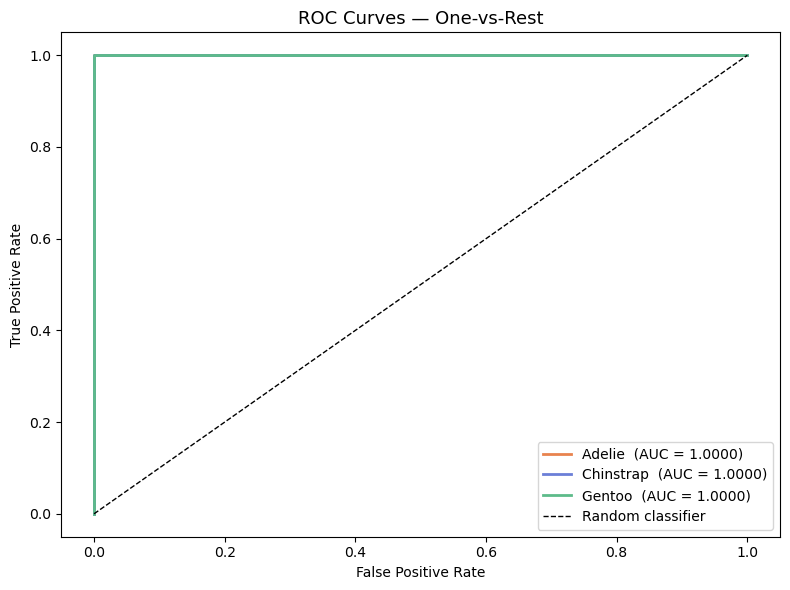

In [30]:
classes   = best_pipeline.classes_        
y_test_bin = label_binarize(y_test, classes=classes)   

y_score = best_pipeline.predict_proba(X_test)       

colors = ["#E8834E", "#6B7FD7", "#5DBB8A"]

fig, ax = plt.subplots(figsize=(8, 6))

for i, (cls, color) in enumerate(zip(classes, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{cls}  (AUC = {roc_auc:.4f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — One-vs-Rest", fontsize=13)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

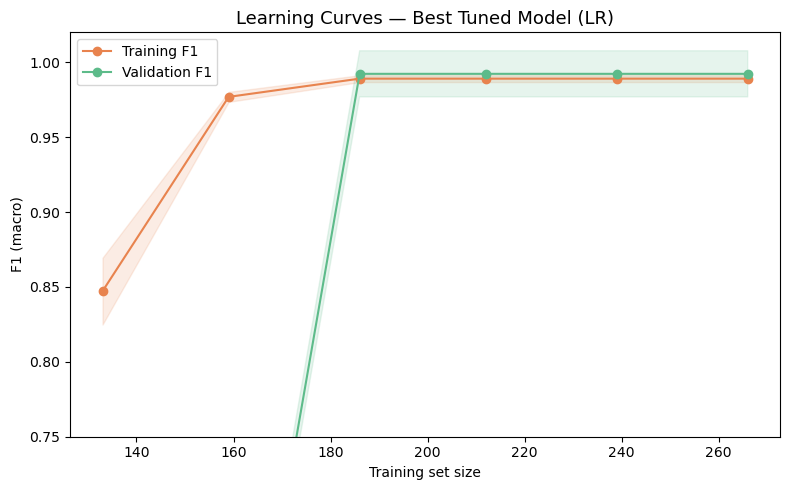

In [31]:
train_sizes, train_scores, val_scores = learning_curve(
    best_pipeline, X, y,
    train_sizes=np.linspace(0.10, 1.0, 10),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="f1_macro",
    n_jobs=-1,
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(train_sizes, train_mean, "o-", color="#E8834E", label="Training F1")
ax.fill_between(train_sizes,
                train_mean - train_std,
                train_mean + train_std,
                alpha=0.15, color="#E8834E")

ax.plot(train_sizes, val_mean, "o-", color="#5DBB8A", label="Validation F1")
ax.fill_between(train_sizes,
                val_mean - val_std,
                val_mean + val_std,
                alpha=0.15, color="#5DBB8A")

ax.set_xlabel("Training set size")
ax.set_ylabel("F1 (macro)")
ax.set_title("Learning Curves — Best Tuned Model (LR)", fontsize=13)
ax.legend()
ax.set_ylim(0.75, 1.02)
plt.tight_layout()
plt.show()

Features:          6
Importances shape: (6,)
             Feature  Importance     Std
0     bill_length_mm      0.2756  0.0499
1      bill_depth_mm      0.0483  0.0262
2             island      0.0295  0.0166
3        body_mass_g      0.0185  0.0137
4  flipper_length_mm      0.0075  0.0094
5                sex      0.0072  0.0088


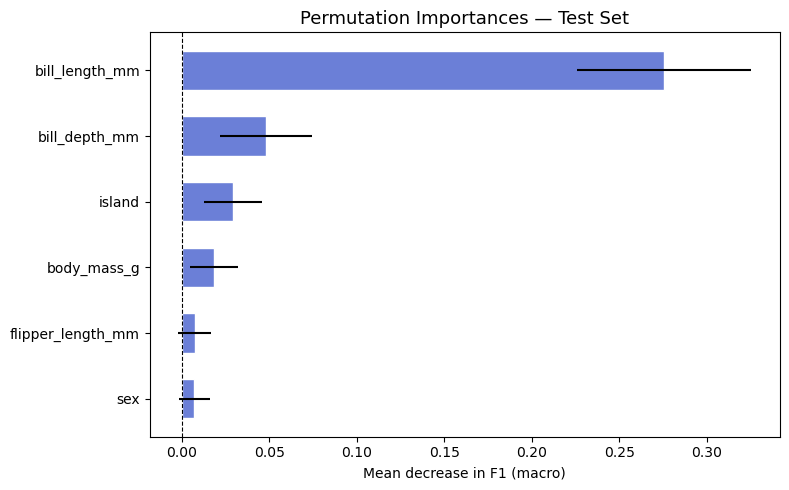

In [32]:
perm = permutation_importance(
    best_pipeline, X_test, y_test,
    n_repeats=30,
    random_state=42,
    scoring="f1_macro",
)

all_feature_names = X.columns.tolist()  

print(f"Features:          {len(all_feature_names)}")
print(f"Importances shape: {perm.importances_mean.shape}")

importance_df = pd.DataFrame({
    "Feature":    all_feature_names,
    "Importance": perm.importances_mean,
    "Std":        perm.importances_std,
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print(importance_df.round(4).to_string())


fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(
    importance_df["Feature"][::-1],
    importance_df["Importance"][::-1],
    xerr=importance_df["Std"][::-1],
    color="#6B7FD7", edgecolor="white", height=0.6,
)
ax.set_xlabel("Mean decrease in F1 (macro)")
ax.set_title("Permutation Importances — Test Set", fontsize=13)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.show()

###  1. Overfitting vs. Underfitting

The model appears to be optimally fit, but with indications of being “too perfect.”

**Evidence:**
- The learning curves show that both training and validation F1 scores converge to nearly 1.0 as the training size increases.
- There is no significant gap between training and validation performance.

**Interpretation:**
- No overfitting → no divergence between train and validation  
- No underfitting → both scores are extremely high  

However, such perfect convergence strongly suggests that the task has become *trivially separable* for the model due to highly informative features.


###  2. Hardest Species to Classify

In this evaluation, no species appears difficult to classify:

- Confusion matrix: **0 misclassifications**
- F1-score: **1.0000 for all classes**
- AUC: **1.0000 for all classes**

**Deeper insight:**
From Task 1, Adelie and Chinstrap showed overlap in PCA space. However, in the full feature space:

- The model leverages additional dimensions (especially bill measurements)
- This allows it to construct a decision boundary that perfectly separates even overlapping groups


### 3. Key Feature Drivers

Permutation importance reveals a **strong feature hierarchy**:

**Primary driver:**
- **bill_length_mm (~0.27)** → dominant feature  
  - Shuffling this feature significantly degrades model performance

**Secondary driver:**
- bill_depth_mm → provides additional separation

**Moderate influence:**
- island → contributes as a contextual signal

**Minimal impact:**
- flipper_length_mm  
- sex  

**Interpretation:**
The model relies primarily on **bill morphology**, which provides strong biological separation between species.

### 4. Data Leakage & Evaluation Concerns

While there is no explicit leakage, several **important warning signs** exist:

#### Perfect Performance (F1 = 1.000)

Achieving perfect scores across all metrics is rare and suggests:

- The dataset is highly separable  
- The test set may lack challenging samples  
- The model may not be stress-tested against edge cases  

#### Proxy Feature Risk (island)

- The feature **island** is strongly correlated with species  
- It may act as a **shortcut feature**

This is not direct leakage, but a form of **proxy bias**, where the model relies on indirect signals instead of deeper patterns.

#### Small Test Set

- Test size = **67 samples**
- With such a small sample, it is possible to obtain artificially perfect results if:
  - No borderline cases are included  
  - Class boundaries appear cleaner than they truly are  


### Summary

| Component            | Status            | Insight |
|---------------------|------------------|--------|
| Fit Quality         | Near-perfect     | No bias/variance issues, but suspiciously high |
| Hardest Class       | None             | All classes perfectly separated |
| Top Feature         | bill_length_mm   | Critical for classification |
| Reliability         | Caution       | Perfect scores may not generalize |




### Task 4 — Model Deployment Prototype

1. Serialize the best tuned model (full pipeline including preprocessor) using `joblib.dump()`.
2. Create an **`app.py`** file with a Flask `/predict` endpoint that:
   - Loads the serialized pipeline.
   - Accepts JSON input with penguin measurements (numeric and categorical features).
   - Returns the predicted species and class probabilities.
   - Includes basic input validation.
3. Also add a `/health` endpoint.
4. Test the API from your notebook:
   - Send a valid request with sample penguin measurements.
   - Send an invalid request and verify error handling.
5. Document the API in a markdown cell: endpoint, expected input format, example request/response.


In [33]:
import joblib

joblib.dump(best_pipeline, "penguin_pipeline.joblib")
print("Saved → penguin_pipeline.joblib")

loaded_pipeline = joblib.load("penguin_pipeline.joblib")
test_pred = loaded_pipeline.predict(X_test[:3])
print("Reload check:", test_pred)

Saved → penguin_pipeline.joblib
Reload check: ['Gentoo' 'Chinstrap' 'Adelie']


In [34]:
import subprocess, time, sys

server = subprocess.Popen(
    [sys.executable, "app.py"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
)

time.sleep(3)  
print("Flask server started (PID:", server.pid, ")")

Flask server started (PID: 2936 )


In [35]:
print(server.poll())

None


In [36]:
import requests

resp = requests.get("http://127.0.0.1:5000/health")
print("Status:", resp.status_code)
print("Body:  ", resp.json())

Status: 200
Body:   {'model': 'Logistic Regression - Palmer Penguins', 'status': 'ok', 'version': '1.0.0'}


In [37]:
resp = requests.post(
    "http://127.0.0.1:5000/predict",
    json={
        "island":            "Biscoe",
        "bill_length_mm":    46.1,
        "bill_depth_mm":     13.2,
        "flipper_length_mm": 211.0,
        "body_mass_g":       4500.0,
        "sex":               "Male",
    }
)
print("Status:", resp.status_code)
print("Body:  ", resp.json())

Status: 200
Body:   {'prediction': 'Gentoo', 'probabilities': {'Adelie': 0.0273, 'Chinstrap': 0.0212, 'Gentoo': 0.9515}}


In [38]:
resp1 = requests.post(
    "http://127.0.0.1:5000/predict",
    json={"island": "Biscoe", "bill_length_mm": 46.1},
)
print("Missing field →", resp1.status_code, resp1.json())


resp2 = requests.post(
    "http://127.0.0.1:5000/predict",
    json={
        "island": "INVALID_ISLAND",
        "bill_length_mm": 46.1, "bill_depth_mm": 13.2,
        "flipper_length_mm": 211.0, "body_mass_g": 4500.0,
        "sex": "Male",
    },
)
print("Invalid island  →", resp2.status_code, resp2.json())


resp3 = requests.post(
    "http://127.0.0.1:5000/predict",
    data="not json",
    headers={"Content-Type": "text/plain"},
)
print("Wrong MIME type →", resp3.status_code, resp3.json())


resp4 = requests.post(
    "http://127.0.0.1:5000/predict",
    json={
        "island": "Dream",
        "bill_length_mm": 999.0,   
        "bill_depth_mm": 13.2,
        "flipper_length_mm": 211.0,
        "body_mass_g": 4500.0,
        "sex": "Female",
    },
)
print("Out of range →", resp4.status_code, resp4.json())

Missing field → 422 {'error': 'Missing required field: bill_depth_mm'}
Invalid island  → 422 {'error': 'island must be one of: Biscoe, Dream, Torgersen'}
Wrong MIME type → 415 {'error': 'Content-Type must be application/json'}
Out of range → 422 {'error': 'bill_length_mm out of plausible range (10-100 mm)'}


In [39]:
server.terminate()
print("Flask server stopped.")

Flask server stopped.


### Overview

A lightweight Flask REST API that serves the best tuned Logistic Regression
pipeline from Task 2/3 to predict penguin species from physical measurements.
The full preprocessing pipeline (StandardScaler + OneHotEncoder) is bundled
inside penguin_pipeline.pkl — no separate preprocessing step needed at inference.

#### GET /health

Returns service status and model metadata.

Example request:
    GET http://127.0.0.1:5000/health

Example response (200):
    {
      "status":  "ok",
      "model":   "Logistic Regression - Palmer Penguins",
      "version": "1.0.0"
    }


#### POST /predict

Accepts penguin measurements as JSON and returns the predicted species
along with class probabilities for all three species.

Headers:
    Content-Type: application/json

Request body — all 6 fields are required:

    Field               Type     Valid values / range
    ----------------    ------   ----------------------------------
    island              string   "Biscoe", "Dream", "Torgersen"
    bill_length_mm      float    10 – 100 mm
    bill_depth_mm       float    5  – 50  mm
    flipper_length_mm   float    100 – 300 mm
    body_mass_g         float    500 – 8000 g
    sex                 string   "Male", "Female"

Example request:
    POST http://127.0.0.1:5000/predict
    {
      "island":            "Biscoe",
      "bill_length_mm":    46.1,
      "bill_depth_mm":     13.2,
      "flipper_length_mm": 211.0,
      "body_mass_g":       4500.0,
      "sex":               "Male"
    }

Example response (200):
    {
      "prediction": "Gentoo",
      "probabilities": {
        "Adelie":    0.0273,
        "Chinstrap": 0.0212,
        "Gentoo":    0.9515
      }
    }



### Error responses

    Status   Cause                              Example message
    ------   --------------------------------   -----------------------------------------
    415      Wrong Content-Type header          "Content-Type must be application/json"
    422      Missing field                      "Missing required field: bill_depth_mm"
    422      Invalid categorical value          "island must be one of: Biscoe, Dream, Torgersen"
    422      Numeric value out of range         "bill_length_mm out of plausible range (10-100 mm)"



### Running locally

    pip install flask joblib scikit-learn pandas
    python app.py
    # Serving on http://127.0.0.1:5000



### Verified test results

    GET  /health         200  status: ok
    POST /predict        200  prediction: Gentoo  (Adelie: 0.0273, Chinstrap: 0.0212, Gentoo: 0.9515)
    POST missing field   422  Missing required field: bill_depth_mm
    POST invalid island  422  island must be one of: Biscoe, Dream, Torgersen
    POST wrong MIME      415  Content-Type must be application/json
    POST out of range    422  bill_length_mm out of plausible range (10-100 mm)


### Production notes

- For production, replace Flask dev server with gunicorn:
      gunicorn -w 4 app:app
- Add authentication (API key or JWT) before exposing publicly.
- The island feature is a strong geographic proxy — if new data comes
  from an unrecognised island, the model will fall back to numeric features
  only (OneHotEncoder handle_unknown="ignore" silently zeros unknown categories).